# ***Analise de dados - Education Inequality Data***
(***Dataset*** : https://www.kaggle.com/datasets/shamimhasan8/education-inequality-data
)

# ***Predição desigualdade educacional***

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import  mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVR
from sklearn.tree import plot_tree, DecisionTreeRegressor
from sklearn.ensemble import  RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

##***1. Coleta de Dados***

In [139]:
df = pd.read_csv('/content/education_inequality_data.csv') # diretório do arquivo
df.head()

,id,school_name,state,school_type,grade_level,funding_per_student_usd,avg_test_score_percent,student_teacher_ratio,percent_low_income,percent_minority,internet_access_percent,dropout_rate_percent
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [140]:
df.columns

Index(['id', 'school_name', 'state', 'school_type', 'grade_level',
       'funding_per_student_usd', 'avg_test_score_percent',
       'student_teacher_ratio', 'percent_low_income', 'percent_minority',
       'internet_access_percent', 'dropout_rate_percent'],
      dtype='object')

In [141]:
# renomear um ou mais nomes de colunas
# o método rename permite renomear o dataframe
# um dicionário é enviado para a propriedade columns
# a troca é realizada entre as chaves e os valores do dicionário
df.rename(columns={'id':'Matricula',
                   'school_name':'Nome da Escola',
                   'state': 'Estado',
                   'school_type': 'Tipo de Escola',
                   'grade_level': 'Nível de Ensino',
                   'funding_per_student_usd': 'Financiamento por Aluno',
                   'avg_test_score_percent': 'Nota Média por Teste',
                   'student_teacher_ratio': 'Taxa de Estudantes por Professores',
                   'percent_low_income': 'Porcentagem de Baixa Renda',
                   'percent_minority': 'Porcentagem de Minorias',
                   'internet_access_percent': 'Porcentagem de Acesso à Internet',
                   'dropout_rate_percent': 'Taxa de Dropout'
                   }, inplace=True)
df.head()

,Matricula,Nome da Escola,Estado,Tipo de Escola,Nível de Ensino,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Taxa de Dropout
0,1,Bowman High School,Michigan,Private,High,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Charter,Middle,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Middle,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementary,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementary,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [142]:
# renomear uma ou mais informações do dataframe
# a troca é realizada entre as chaves e os valores do dicionário
substituicoes = {
    'PRIVADO': 'Privada',
    'PUBLICO': 'Publica',
    'Charter': 'Publica Independente',
    'Elementary': 'Elementar/fundamental I',
    'Middle': 'Ensino Fundamental II',
    'High': 'Ensino Médio'
}
df = df.replace(substituicoes)

df.head()

,Matricula,Nome da Escola,Estado,Tipo de Escola,Nível de Ensino,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Taxa de Dropout
0,1,Bowman High School,Michigan,Private,Ensino Médio,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Publica Independente,Ensino Fundamental II,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Ensino Fundamental II,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementar/fundamental I,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementar/fundamental I,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


In [143]:
atributos_numericos = ['Financiamento por Aluno', 'Nota Média por Teste', 'Taxa de Estudantes por Professores', 'Porcentagem de Baixa Renda', 'Porcentagem de Minorias','Porcentagem de Acesso à Internet' ]

In [144]:
print('Counts() dos atributos numéricos')
df[['Financiamento por Aluno', 'Nota Média por Teste', 'Taxa de Estudantes por Professores','Porcentagem de Baixa Renda','Porcentagem de Minorias', 'Porcentagem de Acesso à Internet']].value_counts()

Counts() dos atributos numéricos


,,,,,,count
Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,
24981.90,44.1,28.4,75.9,13.0,78.4,1
5012.97,48.5,12.2,70.1,19.5,77.0,1
5025.47,44.7,17.9,54.8,31.3,67.2,1
5028.53,75.3,26.1,11.9,63.4,64.2,1
5036.13,41.1,26.2,60.9,75.0,95.9,1
...,...,...,...,...,...,...
5292.17,65.4,21.1,71.4,16.2,68.6,1
5291.51,54.2,20.0,15.5,38.8,53.7,1
5284.34,85.3,14.3,93.3,76.9,83.9,1


In [145]:
atributos_categoricos = ['Nível de Ensino', 'Estado', 'Tipo de Escola']

In [186]:
'''
Analise do resultado.
A distribuição de dados entre os 3 Níveis de Ensino e os 3 Tipos de Escola está bem balanceada. O Estado do Texas é o mais frequente no dataset.
'''
for col in ['Nível de Ensino', 'Estado', 'Tipo de Escola']:
    print(f"Contagem para: {col}")
    print(df[col].value_counts())
    print("-" * 30)

Contagem para: Nível de Ensino
Nível de Ensino
Elementar/fundamental I    345
Ensino Médio               330
Ensino Fundamental II      325
Name: count, dtype: int64
------------------------------
Contagem para: Estado
Estado
Texas             119
Florida           110
Georgia           107
Illinois          102
Ohio              101
California         97
North Carolina     96
New York           95
Michigan           89
Pennsylvania       84
Name: count, dtype: int64
------------------------------
Contagem para: Tipo de Escola
Tipo de Escola
Private                 355
Publica Independente    326
Public                  319
Name: count, dtype: int64
------------------------------


In [147]:
atributos_ordinais = ['Nível de Ensino']

In [148]:
print('Counts() dos atributos ordinais')
df[['Nível de Ensino']].value_counts()

Counts() dos atributos ordinais


,count
Nível de Ensino,
Elementar/fundamental I,345
Ensino Médio,330
Ensino Fundamental II,325


In [149]:
atributos_nominais = ['Estado', 'Tipo de Escola']

In [150]:
print('Counts() dos atributos nominais')
df[['Estado', 'Tipo de Escola']].value_counts()

Counts() dos atributos nominais


Estado          Tipo de Escola      
Texas           Public                  44
                Private                 43
California      Public                  39
North Carolina  Private                 39
Florida         Public                  39
Georgia         Private                 38
Ohio            Private                 37
Florida         Private                 37
Illinois        Publica Independente    37
Michigan        Private                 37
Georgia         Public                  36
Ohio            Publica Independente    35
Florida         Publica Independente    34
Illinois        Private                 34
Georgia         Publica Independente    33
New York        Publica Independente    33
Pennsylvania    Private                 32
California      Publica Independente    32
Texas           Publica Independente    32
New York        Private                 32
Illinois        Public                  31
Michigan        Publica Independente    31
New York        Public                  30
Pennsylvania    Publica Independente    30
Ohio            Public                  29
North Carolina  Publica Independente    29
                Public                  28
California      Private                 26
Pennsylvania    Public                  22
Michigan        Public                  21
Name: count, dtype: int64

In [151]:
rotulo =  'Taxa de Dropout'

## 2. Analise Exploratoria de Dados

In [152]:
'''
Conseguimos verificar que a Taxa dropout nosso rotulo tem uma media de 7.7 e desvio padrao de 4.21.
'''
df[atributos_numericos + [rotulo]].describe()

,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Taxa de Dropout
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,15154.160180,70.001000,19.733200,53.756400,49.652000,74.688500,7.765600
std,5931.384208,17.703408,5.823201,24.021689,25.241025,14.433086,4.214452
min,5012.970000,40.000000,10.000000,10.200000,5.000000,50.000000,0.500000
25%,9726.040000,54.575000,14.800000,33.400000,29.300000,62.400000,4.050000
50%,15362.465000,69.900000,19.400000,54.100000,49.450000,74.750000,7.685000
75%,20280.007500,85.625000,25.000000,74.600000,69.950000,87.325000,11.492500
max,24981.900000,100.000000,30.000000,94.900000,94.900000,100.000000,14.990000


In [153]:
df[atributos_categoricos + [rotulo]].describe(include=['object'])

,Nível de Ensino,Estado,Tipo de Escola
count,1000,1000,1000
unique,3,10,3
top,Elementar/fundamental I,Texas,Private
freq,345,119,355


In [154]:
Tipo_de_Escola  = df['Tipo de Escola'].unique().tolist()

In [155]:
# indicadores estatisticos dos atributos categoricos
# hipótese: O tipo de escola é determinante para o acesso a Faculdade
for escola in Tipo_de_Escola:
  print('Indicadores numéricos do ' + escola + '\n')
  print(df[[rotulo]][(df['Tipo de Escola'] == escola)].describe(),'\n\n\n')
print('\n\n\n')

Indicadores numéricos do Private

       Taxa de Dropout
count       355.000000
mean          7.760479
std           4.147852
min           0.590000
25%           4.165000
50%           7.620000
75%          11.405000
max          14.940000 



Indicadores numéricos do Publica Independente

       Taxa de Dropout
count       326.000000
mean          8.094693
std           4.247482
min           0.500000
25%           4.500000
50%           8.205000
75%          11.970000
max          14.950000 



Indicadores numéricos do Public

       Taxa de Dropout
count       319.000000
mean          7.434984
std           4.241100
min           0.560000
25%           3.690000
50%           7.230000
75%          11.235000
max          14.990000 









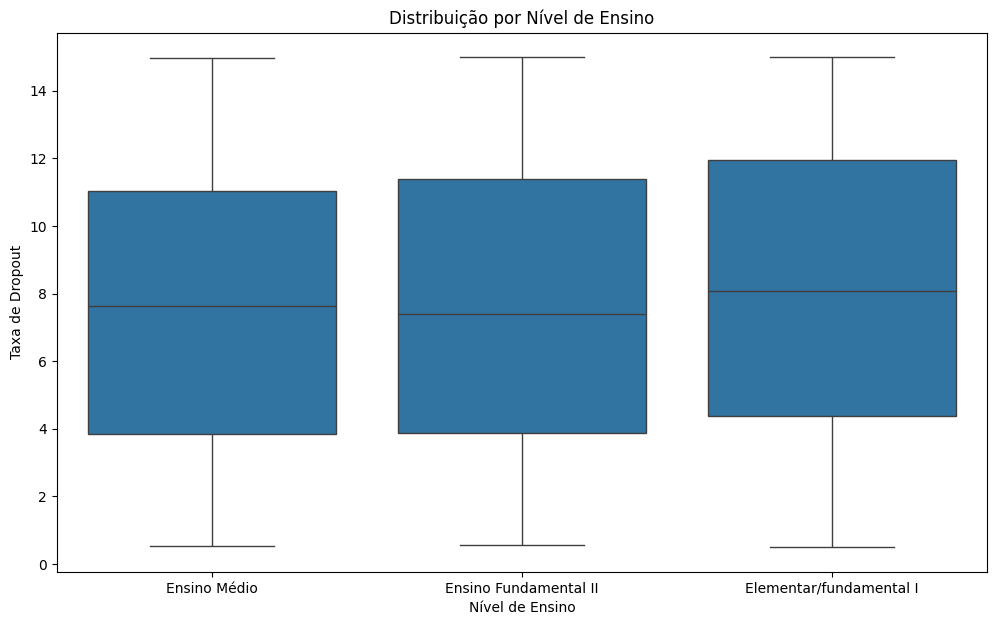

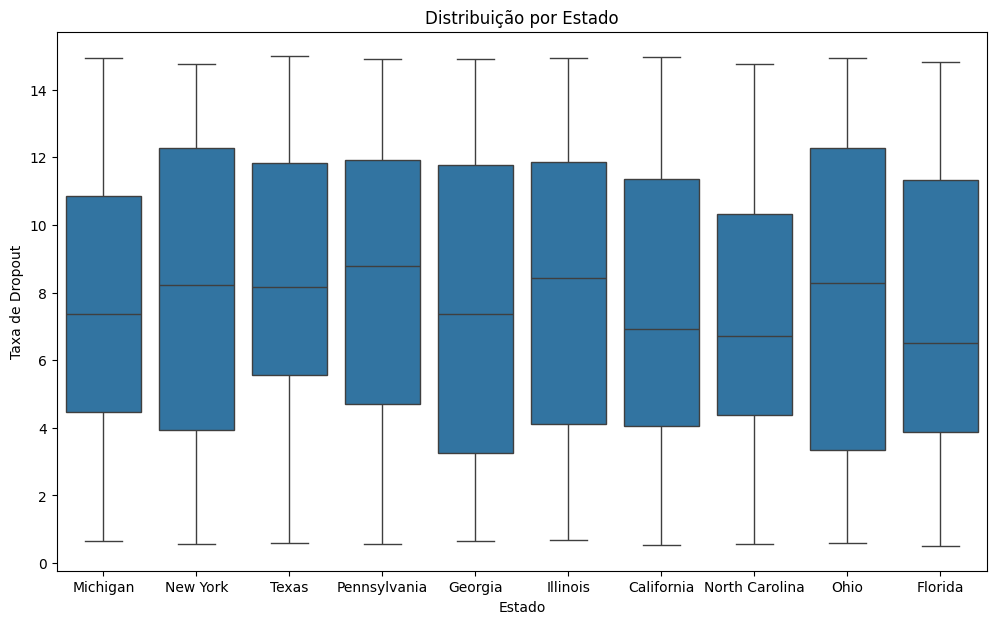

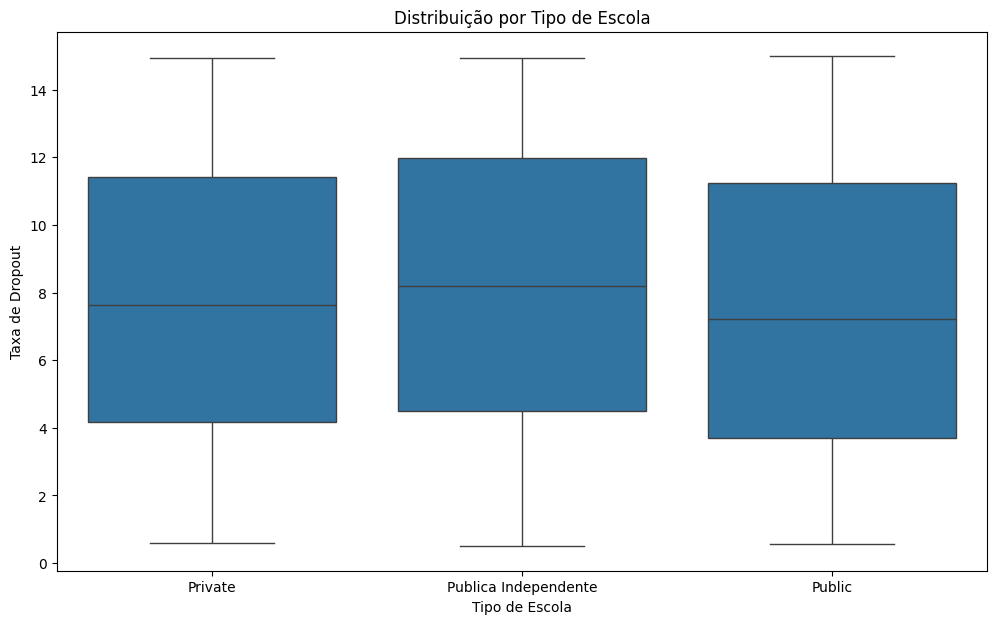

In [156]:
# gráfico de boxplots
# hipótese: O tipo de escola é determinante para o acesso a Faculdade
for atributos_categorico in atributos_categoricos:
  plt.figure(figsize=(12, 7))
  sns.boxplot(x=atributos_categorico, y=rotulo, data=df[[atributos_categorico, rotulo]])
  plt.title('Distribuição por ' + atributos_categorico)
  plt.show()

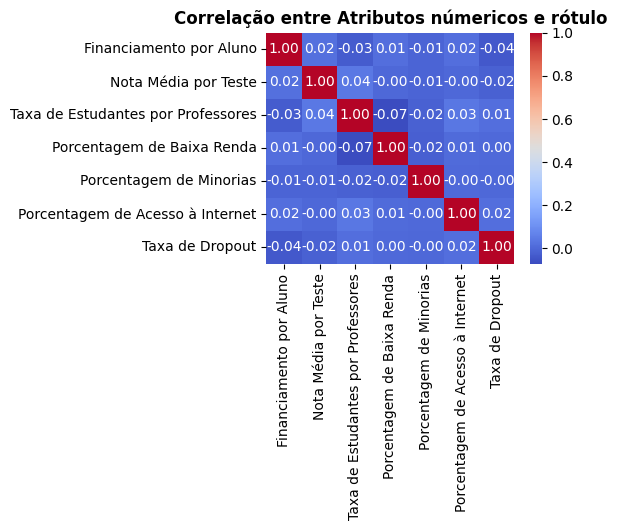

In [157]:
# Correlação entre os atributos categoricos
# # hipótese: O tipo de escola é determinante para o acesso a Faculdade
plt.figure(figsize=(4, 3))
matriz_corr = df[atributos_numericos + [rotulo]].corr()
sns.heatmap(matriz_corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Correlação entre Atributos númericos e rótulo', fontweight='bold')
plt.show()

## 3. PRÉ-PROCESSAMENTO

In [158]:
#Removendo as linhas com valores NAN
df_sen_NAN = df.dropna(axis=0)

In [159]:
#Remvendo dados duplicados
df_sem_duplicatas = df_sen_NAN.drop_duplicates()

In [160]:
#Copiando após a limpeza de dados
df_limpo = df_sem_duplicatas.copy()

In [161]:
df_limpo.head()

,Matricula,Nome da Escola,Estado,Tipo de Escola,Nível de Ensino,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Taxa de Dropout
0,1,Bowman High School,Michigan,Private,Ensino Médio,9575.80,65.9,17.5,30.0,44.0,74.1,3.44
1,2,Foster High School,Michigan,Publica Independente,Ensino Fundamental II,16733.10,87.3,24.2,93.5,40.1,79.9,8.67
2,3,Henson High School,New York,Public,Ensino Fundamental II,24890.74,72.8,27.0,58.1,35.8,51.1,14.75
3,4,Weaver High School,Texas,Private,Elementar/fundamental I,6857.49,81.5,26.2,82.7,72.0,55.5,13.45
4,5,King Elementary School,Michigan,Public,Elementar/fundamental I,16910.73,44.7,20.2,41.4,16.1,57.8,6.98


### 3.1 Transformação dos atributos categóricos

#### 3.1.1 Atributos categóricos ordinais

In [162]:
# transformação de variaveis categóricas ordinais
substituicoes = {
    'Privada' : 0,
    'Publica' : 1,
    'Publica Independente' : 2,
    'Elementar/fundamental I' : 3,
    'Ensino Fundamental II' : 4,
    'Ensino Médio': 5,
}
df_ordinais_transformadas = df_limpo[atributos_ordinais].replace(substituicoes)

df_ordinais_transformadas.head()

/tmp/ipython-input-1782902760.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_ordinais_transformadas = df_limpo[atributos_ordinais].replace(substituicoes)


,Nível de Ensino
0,5
1,4
2,4
3,3
4,3


In [163]:
# transformação de variaveis categóricas nominais através da classe OneHotEncoder
# novas colunas a partir dos grupos existentes nos atributos categóricos
# será uma coluna nova para cada grupo
# isso garante que atributos categóricos nominais não tenham relação de grandeza
encoder = OneHotEncoder(sparse_output=False)  # sparse_output=False garante que o tipo de dado seja numpy array
encoded_array = encoder.fit_transform(df_limpo[atributos_nominais]) # transforma os dados

novas_colunas = encoder.get_feature_names_out(atributos_nominais) # nomes das novas colunas

df_nominais_transformadas = pd.DataFrame(                           # pd.Dataframe gera dataframe
                                           encoded_array,             # dados transformados
                                           columns= novas_colunas,    # nomes das novas colunas
                                           index=df_limpo.index  # indíces das linhas do dataframe
                                           )

df_nominais_transformadas.head()

,Estado_California,Estado_Florida,Estado_Georgia,Estado_Illinois,Estado_Michigan,Estado_New York,Estado_North Carolina,Estado_Ohio,Estado_Pennsylvania,Estado_Texas,Tipo de Escola_Private,Tipo de Escola_Public,Tipo de Escola_Publica Independente
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [164]:
# une todas transformações realizadas em um único dataframe
df_transformado = pd.concat(                                        # pd.concat realiza a união dos dataframes
                              [df_limpo[atributos_numericos],  # dataframe com atributos numéricos
                               df_nominais_transformadas,           # dataframe com atributos categóricos nominais
                               df_ordinais_transformadas,           # dataframe com atributos categóricos ordinais
                               df_limpo[rotulo]
                              ],
                              axis=1                                # acessa as colunas dos dataframes
                            )

df_transformado.head()

,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Estado_California,Estado_Florida,Estado_Georgia,Estado_Illinois,...,Estado_New York,Estado_North Carolina,Estado_Ohio,Estado_Pennsylvania,Estado_Texas,Tipo de Escola_Private,Tipo de Escola_Public,Tipo de Escola_Publica Independente,Nível de Ensino,Taxa de Dropout
0,9575.80,65.9,17.5,30.0,44.0,74.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5,3.44
1,16733.10,87.3,24.2,93.5,40.1,79.9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4,8.67
2,24890.74,72.8,27.0,58.1,35.8,51.1,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4,14.75
3,6857.49,81.5,26.2,82.7,72.0,55.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3,13.45
4,16910.73,44.7,20.2,41.4,16.1,57.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3,6.98


In [165]:
df_transformado.head()

,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Estado_California,Estado_Florida,Estado_Georgia,Estado_Illinois,...,Estado_New York,Estado_North Carolina,Estado_Ohio,Estado_Pennsylvania,Estado_Texas,Tipo de Escola_Private,Tipo de Escola_Public,Tipo de Escola_Publica Independente,Nível de Ensino,Taxa de Dropout
0,9575.80,65.9,17.5,30.0,44.0,74.1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5,3.44
1,16733.10,87.3,24.2,93.5,40.1,79.9,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4,8.67
2,24890.74,72.8,27.0,58.1,35.8,51.1,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4,14.75
3,6857.49,81.5,26.2,82.7,72.0,55.5,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3,13.45
4,16910.73,44.7,20.2,41.4,16.1,57.8,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3,6.98


### 3.5 Padronização (Z-score)

In [166]:
# Transformando as dados em float
df_transformado = df_transformado.astype(float)

In [167]:
df_preprocessado_nao_padronizado = df_transformado.copy()

In [168]:
# Padronização (Z-score) das variáveis numéricas através do StandardScaler()
# garante que as variáveis numéricas estejam na mesma escala
scaler = StandardScaler()

df_preprocessado_padronizado = df_preprocessado_nao_padronizado.copy()          # copia os dados de um dataframe para outro
z = scaler.fit_transform(df_preprocessado_nao_padronizado[atributos_numericos]) # padroniza (z-score) os atributos numéricos
df_preprocessado_padronizado.loc[:, atributos_numericos] = z                    # atualiza o dataframe com os dados padronizados

df_preprocessado_padronizado.head()

,Financiamento por Aluno,Nota Média por Teste,Taxa de Estudantes por Professores,Porcentagem de Baixa Renda,Porcentagem de Minorias,Porcentagem de Acesso à Internet,Estado_California,Estado_Florida,Estado_Georgia,Estado_Illinois,...,Estado_New York,Estado_North Carolina,Estado_Ohio,Estado_Pennsylvania,Estado_Texas,Tipo de Escola_Private,Tipo de Escola_Public,Tipo de Escola_Publica Independente,Nível de Ensino,Taxa de Dropout
0,-0.940953,-0.231766,-0.383692,-0.989451,-0.224033,-0.040795,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,5.0,3.44
1,0.266334,0.977645,0.767453,1.655316,-0.378621,0.361261,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,8.67
2,1.642357,0.158184,1.248529,0.180910,-0.549064,-1.635153,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,4.0,14.75
3,-1.399475,0.649861,1.111079,1.205497,0.885827,-1.330145,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,3.0,13.45
4,0.296297,-1.429875,0.080202,-0.514643,-1.329930,-1.170709,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,3.0,6.98


## 4. Divisão de dados

In [169]:
# lista com nomes dos atributos após o pré-processamento
atributos = df_preprocessado_padronizado.drop(columns=[rotulo]).columns.tolist()

In [170]:
print(atributos)

['Financiamento por Aluno', 'Nota Média por Teste', 'Taxa de Estudantes por Professores', 'Porcentagem de Baixa Renda', 'Porcentagem de Minorias', 'Porcentagem de Acesso à Internet', 'Estado_California', 'Estado_Florida', 'Estado_Georgia', 'Estado_Illinois', 'Estado_Michigan', 'Estado_New York', 'Estado_North Carolina', 'Estado_Ohio', 'Estado_Pennsylvania', 'Estado_Texas', 'Tipo de Escola_Private', 'Tipo de Escola_Public', 'Tipo de Escola_Publica Independente', 'Nível de Ensino']


### 4.1 Não padronizados

In [171]:
# Divide os dados não padronizados em treino(70%) e teste(30%)
# alguns modelos (Árvore de decisão, Random Forest e outros) utilizam dados NÃO padronizados no treino
divisao_nao_padronizado = train_test_split(df_preprocessado_nao_padronizado[atributos], # atributos
                                           df_preprocessado_nao_padronizado[rotulo],    # rótulo
                                           test_size=0.3,                               # proporção treino teste. Ex: 0.3 = 30% de teste
                                           random_state=42)                             # pseudoaleatório
atributos_treino_nao_pad, atributos_teste_nao_pad, rotulo_treino_nao_pad, rotulo_teste_nao_pad = divisao_nao_padronizado

### 4.2 Padronizados

In [172]:
# Divide os dados padronizados em treino(70%) e teste(30%)
# alguns modelos (SVM, k-NN, Redes Neurais e outros) utilizam dados padronizados no treino

divisao_padronizado = train_test_split(df_preprocessado_padronizado[atributos], # atributos
                                       df_preprocessado_padronizado[rotulo],    # rótulo
                                       test_size=0.3,                           # proporção treino teste. Ex: 0.3 = 30% de teste
                                       random_state=42)                         # pseudoaleatório
atributos_treino_pad, atributos_teste_pad, rotulo_treino_pad, rotulo_teste_pad = divisao_padronizado

### 5.1 Modelo Árvore de Decisão (Decision Tree)

In [173]:
# instância da Árvore de decisão
decision_tree_regressor = DecisionTreeRegressor(random_state = 42)

In [174]:
# hiperparâmetros do GridSearchCV
# GridSearchCV testa diversos hiperparâmetros no treinamento. Após isso, encontra os melhores parâmetros
param_grid_ad = {
    'max_depth'         : [4,6,8,10,12],  # quantidade de níveis (desde o nó raiz até a última folha)
    'min_samples_split' : [2, 4],         # quantidade mínima de amostras por nó
    'min_samples_leaf'  : [2, 4],         # quantidade mínima de amostras de um tipo por nó
}

In [175]:
# instância do GridSearchCV
grid_search_ad = GridSearchCV(
    estimator=decision_tree_regressor,  # instância do modelo
    param_grid=param_grid_ad,           # parâmetros GridSearchCV
    cv=5,                               # cross-validation
    scoring='neg_mean_squared_error',   # métrica de validação
    n_jobs=-1,                          # CPU's utilizadas
    verbose=3                           # mensagens durante o treino
)

In [176]:
# treino
grid_search_ad.fit(atributos_treino_nao_pad, rotulo_treino_nao_pad)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=DecisionTreeRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [4, 6, 8, 10, 12],
                         'min_samples_leaf': [2, 4],
                         'min_samples_split': [2, 4]},
             scoring='neg_mean_squared_error', verbose=3)

In [177]:
#rótulos preditos pelo teste
rotulo_predito_ad = grid_search_ad.predict(atributos_teste_nao_pad)

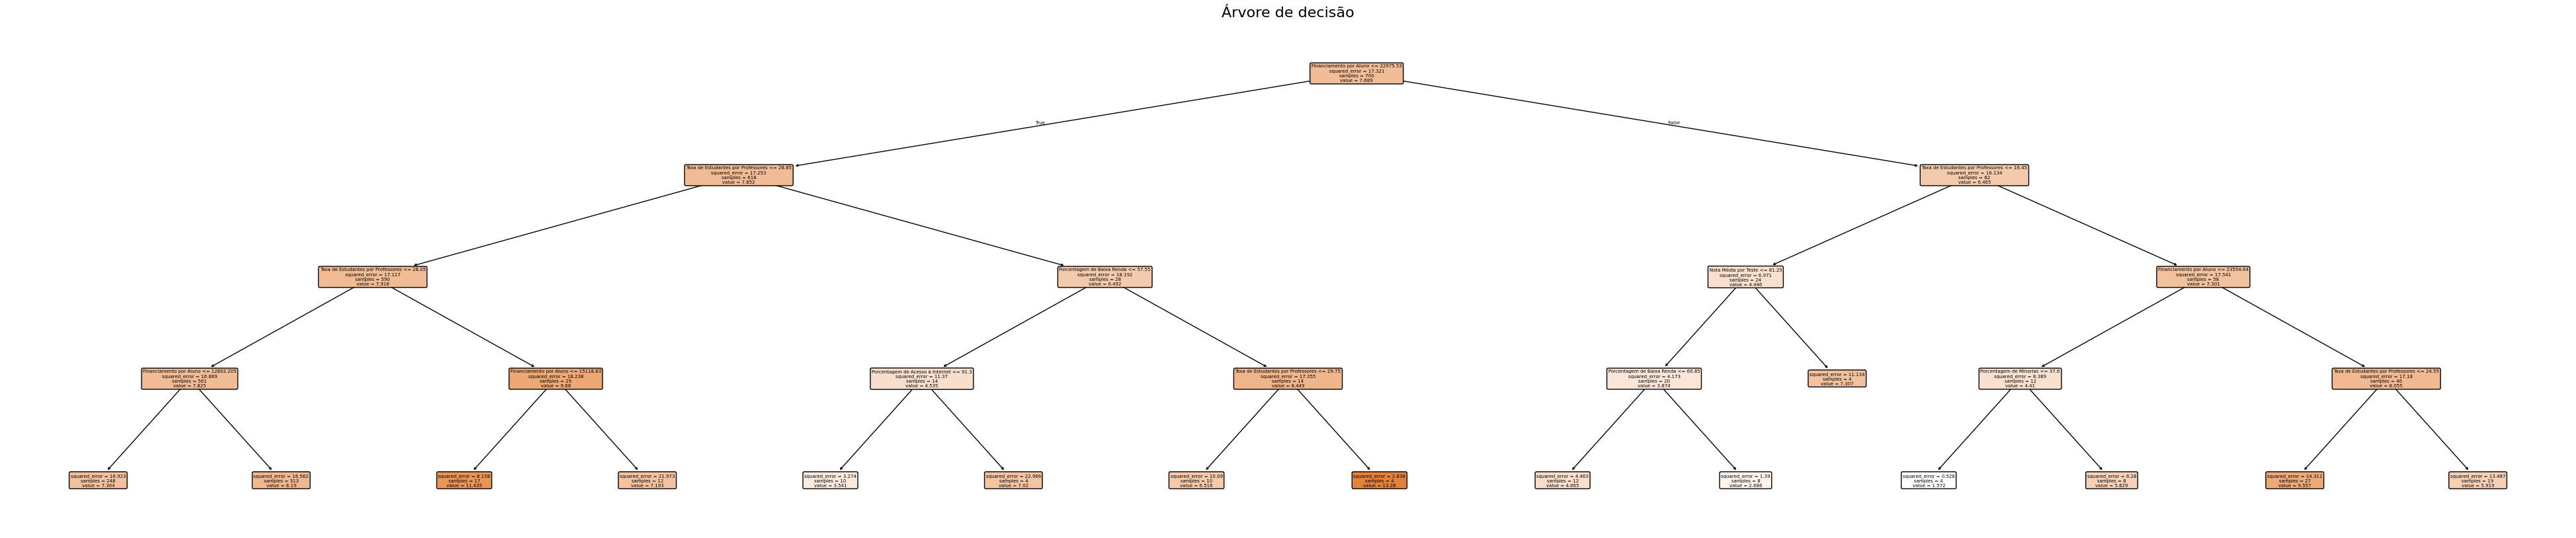

In [178]:
# diagrama da Árvore de Decisão
plt.figure(figsize=(50, 10))

atributos_ad = grid_search_ad.feature_names_in_

plot_tree(grid_search_ad.best_estimator_, # melhor modelo selecionado
          feature_names= atributos_ad,    # atributos
          filled=True,                    # atribui uma tonalidade diferentes aos nós, quanto mais escura a cor, mais confiante o resultado
          rounded=True,                   # arredonda o visual dos nós
          fontsize=5)                     # tamanho da letra

plt.title('Árvore de decisão', fontsize=16)
plt.show()

In [179]:
# métrica R²
r2_ad = r2_score(rotulo_teste_nao_pad, rotulo_predito_ad) * 100.0
print('R² (Árvore de Decisão): ' + str(round(r2_ad,2)))

R² (Árvore de Decisão): -10.09


In [180]:
# métrica RMSE(Root Mean Squared Erro)
rmse_ad = root_mean_squared_error(rotulo_teste_nao_pad, rotulo_predito_ad)
print('RMSE (Árvore de Decisão): ' + str(round(rmse_ad,2)))

RMSE (Árvore de Decisão): 4.54


In [181]:
# métrica MAE(Mean Absolute Error)
mae_ad = mean_absolute_error(rotulo_teste_nao_pad, rotulo_predito_ad)
print('MAE (Árvore de Decisão): ' + str(round(mae_ad,2)))

MAE (Árvore de Decisão): 3.97


## 6. Validação
Verificação da performance do modelo


In [182]:
'''
Conforme vimos nos graficos o rotulo taxa de dropout não tem uma correlãcão com os atributos e com isso temos um R² negativo, o que comprova que não
podemos prever a 'Taxa de Dropout' com os atributos fornecidos.
'''
print('R² (Árvore de decisão): ' + str(round(r2_ad, 2)) + '%')

R² (Árvore de decisão): -10.09%


### 6.2 Métrica RMSE
Indica o erro médio quadrático do modelo. Quão mais próximo de zero, melhor

In [183]:
print('RMSE (Árvore de decisão): ' + str(round(rmse_ad, 2)))

RMSE (Árvore de decisão): 4.54


### 6.3 Métrica MAE
Indica o erro médio absoluto do modelo. Quão mais próximo de zero, melhor

In [184]:
print('MAE (Árvore de decisão): ' + str(round(mae_ad, 2)))

MAE (Árvore de decisão): 3.97
